<a href="https://colab.research.google.com/github/KonstantinBlank/BikeSharingDemandPrediction/blob/main/BikeSharingDemandPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Authors:
* Jagoda Wiecek

* Konstantin Blank

* Baptiste Rimet

#Introduction and Data Selection
The dataset consists of 14 variables, with Rented Bike Count serving as the target variable. These features capture temporal, environmental, and operational conditions that influence bike rental patterns. The variables are:
* Date – Calendar date (year-month-day)
* Rented Bike Count – Integer: Number of bikes rented each hour (target variable)
* Hour – Integer: Hour of the day (0–23)
* Temperature – Continuous: Air temperature in °C
* Humidity – Integer: Relative humidity (%)
* Wind Speed – Continuous: Wind speed in m/s
* Visibility – Integer: Visibility in units of 10 m
* Dew Point Temperature – Continuous: Dew point temperature in °C
* Solar Radiation – Continuous: Solar radiation in MJ/m^2
* Rainfall – Integer: Precipitation amount in mm
* Snowfall – Integer: Snow depth in cm
* Seasons – Categorical: Winter, Spring, Summer, Autumn
* Holiday – Binary: Holiday or non-holiday
* Functioning Day – Binary: Functional (operational) or non-functional hours

Such combination of meteorological data, time-based indicators, and operational status provides a comprehensive foundation for modeling and predicting hourly bike rental demand.

Source of the dataset: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

# Business understanding

## Context and Motivation

Bike-sharing systems are a growing trend in urban mobility, offering sustainable transportation solutions. This project analyzes the Seoul Bike Sharing Demand dataset to explore how factors like weather, time of day, and holidays influence hourly bike usage. While the dataset is specific to Seoul, the analysis provides a practical case study for understanding bike-sharing dynamics, a relevant topic in Denmark, where cycling is a major part of urban life.

## Research question

For bike-sharing operators, balancing supply and demand is critical. Poor management can lead to:

* User frustration due to bike shortages during peak hours.
* Inefficient operations, such as unnecessary bike redistribution if we had managed to find data on bikes locations to combine it with this dataset.

By analyzing historical data, we aim to identify patterns that could help operators anticipate demand and improve resource planning.

Then, our research focuses on the following question: **Which factors explain the variation in hourly bike-sharing demand, and how can this information inform better bike management?**

## Expected insights

Based on initial observations of the dataset, we expect the following factors to influence demand:

* Temperature (°C): Warmer weather likely increases usage
* Rainfall (mm): Rain reduces demand
* Hour of the day (0-23): Peaks during commute times (morning/evening)
* Seasons and holidays: Demand may vary by season and holiday schedules

Therefore, here are our main goals

* Exploratory analysis: Use basic statistics to identify trends
* Regression modeling: Apply models to quantify factor impacts
* Practical takeaways: Provide insights for managing bike availability

## AI acknowledgment

In this project, generative AI was used as an assisting tool, primarily to help with code generation, debugging, and clarification of technical concepts and explanations. All AI-generated content was carefully reviewed, understood, and adapted to our project.

The final implementations, analyses, and interpretations were validated through comparison with course materials, official documentation, and additional external references when relevant. The use of AI did not replace critical thinking or independent work but served as a complementary tool to improve efficiency and clarity.

# Data collection

In [ ]:
#Libraries
import numpy as np # Numerical ops
import pandas as pd # Data handling
import matplotlib.pyplot as plt # Plotting
import seaborn as sns # Statistical plots
import warnings # Warning control
warnings.filterwarnings("ignore") # Hide warnings

#Scikit-learn
from sklearn.pipeline import Pipeline # Model pipeline
from sklearn.linear_model import LinearRegression # Linear model
from sklearn.linear_model import Ridge, Lasso, ElasticNet # Regularized models
from sklearn.tree import DecisionTreeRegressor # Decision tree
from sklearn.ensemble import RandomForestRegressor # Random forest
from sklearn.ensemble import GradientBoostingRegressor # Gradient boosting
from sklearn.feature_selection import RFE # Feature selection
from sklearn.model_selection import train_test_split # Train/test split
from sklearn.model_selection import cross_val_score # Cross-validation
from sklearn.model_selection import cross_val_predict # CV predictions
from sklearn.model_selection import GridSearchCV # Hyperparameter tuning
from sklearn.metrics import mean_squared_error # MSE metric
from sklearn.metrics import r2_score # R2 metric
from sklearn.metrics import PredictionErrorDisplay # Error plots
from sklearn.preprocessing import StandardScaler # Feature scaling

#XGBoost
from xgboost import XGBRegressor # XGBoost model

#PyTorch (Neural Network)
import torch # Deep learning
import torch.nn as nn # NN layers
from torch.utils.data import DataLoader, TensorDataset # Data loading

In [ ]:
data = pd.read_csv('SeoulBikeData.csv', encoding='ISO-8859-1')
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


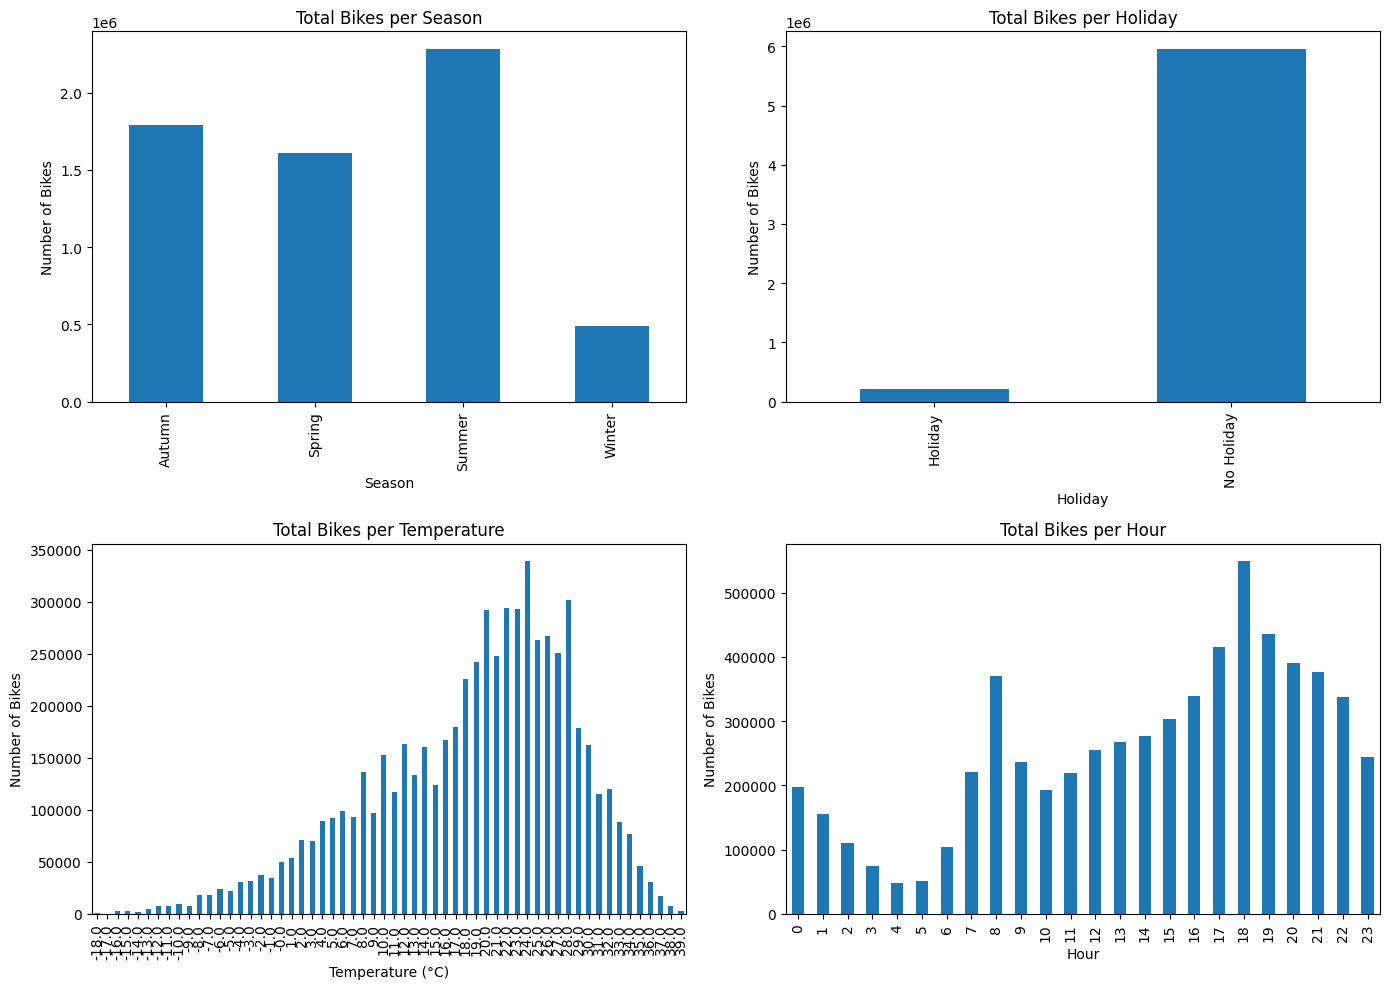

In [ ]:
bikes_per_season = data.groupby("Seasons")["Rented Bike Count"].sum()
bikes_per_holiday = data.groupby("Holiday")["Rented Bike Count"].sum()
bikes_per_temperature = data.groupby(data["Temperature(°C)"].round())["Rented Bike Count"].sum()
bikes_per_hour = data.groupby("Hour")["Rented Bike Count"].sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bikes_per_season.plot(kind="bar", ax=axes[0, 0], title="Total Bikes per Season")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Number of Bikes")

bikes_per_holiday.plot(kind="bar", ax=axes[0, 1], title="Total Bikes per Holiday")
axes[0, 1].set_xlabel("Holiday")
axes[0, 1].set_ylabel("Number of Bikes")

bikes_per_temperature.plot(kind="bar", ax=axes[1, 0], title="Total Bikes per Temperature")
axes[1, 0].set_xlabel("Temperature (°C)")
axes[1, 0].set_ylabel("Number of Bikes")

bikes_per_hour.plot(kind="bar", ax=axes[1, 1], title="Total Bikes per Hour")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("Number of Bikes")

plt.tight_layout()
plt.show()


Looking at the Total Bikes per Season chart, the usage pattern is dominated by warm weather, with Summer recording the highest number of rentals. Autumn surprisingly follows closely behind, suggesting that favorable conditions and user habits persist after the peak summer months. In stark contrast, Winter registers the lowest usage, which is logical given colder weather conditions.

The Total Bikes per Holiday plot reveals that the system is overwhelmingly utilized on "No Holiday" days, while days officially designated as a holiday show minimal usage. This strongly indicates that the bike-sharing service primarily functions as a means of daily commuting during weekdays or casual use during regular weekends, rather than a main activity on public holidays.

The Total Bikes per Temperature chart shows a pronounced peak around the comfortable range of $20\text{°C}$ to $25\text{°C}$, where usage is at its highest. Usage drops sharply at very low temperatures (below $5\text{°C}$) and also decreases at extremely high temperatures (above $30\text{°C}$), establishing an optimal thermal window for riders.

The Total Bikes per Hour chart displays the classic bimodal distribution characteristic of commuter traffic. The plot features a clear morning peak around 8:00 AM and a more substantial, higher afternoon peak between 17:00 and 19:00, reflecting the typical work or school commute times. Usage is at its minimum during the late night and early morning hours (1:00 AM to 6:00 AM)

In [ ]:
filtered_data = data[data['Rented Bike Count'] >= 3000]
display(filtered_data)
print(f"amount of rows where 'Rented Bike Count' >= 3000: {len(filtered_data)}")

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
3834,09/05/2018,3130,18,20.6,41,2.3,2000,6.8,1.10,0.0,0.0,Spring,No Holiday,Yes
4122,21/05/2018,3069,18,21.6,48,2.5,1884,10.1,0.61,0.0,0.0,Spring,No Holiday,Yes
4170,23/05/2018,3123,18,21.7,40,3.5,1987,7.4,1.18,0.0,0.0,Spring,No Holiday,Yes
4290,28/05/2018,3245,18,26.0,39,2.7,1950,10.9,1.07,0.0,0.0,Spring,No Holiday,Yes
4338,30/05/2018,3251,18,23.6,42,2.1,2000,9.9,1.23,0.0,0.0,Spring,No Holiday,Yes
4362,31/05/2018,3119,18,26.4,42,3.1,1995,12.4,0.79,0.0,0.0,Spring,No Holiday,Yes
4386,01/06/2018,3088,18,28.5,36,3.0,1981,11.9,1.21,0.0,0.0,Summer,No Holiday,Yes
4458,04/06/2018,3380,18,24.4,48,1.9,1998,12.6,0.56,0.0,0.0,Summer,No Holiday,Yes
4482,05/06/2018,3227,18,27.1,40,2.8,1811,12.3,1.00,0.0,0.0,Summer,No Holiday,Yes
4530,07/06/2018,3221,18,25.6,57,2.7,1217,16.4,0.96,0.0,0.0,Summer,No Holiday,Yes


amount of rows where 'Rented Bike Count' >= 3000: 31


The dataset has 8761 rows; however, only 31 of them show rented bike count to be higher than 3 thousand. Such sitution may cause problems for models to predict pattern of such high values due tu lack of examples to learn from

The reason for such a high amount of rented bikes might be that, on these certain days, special events took place. It is important to notice that all results show that such high amount of rented bikes occur at 6PM. In South Korea, evening peak hours, when people return from work and school, is between 5M and 7PM, combining peak hours with special events occurring certain days can be a critical reason for such high value of rented bikes.

**09/05/2018** A five-day broadcast culture celebration, the 2018 DMC Festival, began on September 5, featuring Hallyu stars, music festivals, and business events at the Sangam Digital Media City Complex. Artists such as Red Velvet, GFRIEND, Wanna One, and Wheesung attended and performed.

**21/05/2018** Coming of Age Day in South Korea, observed annually on the third Monday of May. This day commemorates youth becoming legal adults (age 19 in South Korea) and assuming full legal responsibility and rights.

**28/05/2018** The K-pop girl group AOA held a promotional event to launch their fifth mini-album, "Bingle Bangle"

**30/05/2018** A press conference for the popular K-drama, "What's Wrong with Secretary Kim", was held at the Times Square in Seoul, attended by the main cast and crew. The drama's production was a significant entertainment event at the time.

**01/06/2018** The "OneWorld" concert tour began in Seoul and included a total of 20 tracks over approximately 3 hours for the sold-out audience.

**07/06/2018** American pianist Jeremy Denk performed a solo recital at the Keumho Art Hall, featuring works by Mozart, Prokofiev, Beethoven, Liszt, and Schumann. This was part of the "Beautiful Thursday Concert" series.

**08/06/2018** The electronic music festival began its weekend of shows on June 8 and ran until June 10 at the Seoul Olympic Stadium, featuring numerous international and regional electronic music acts.

**19/06/2018** Seoul Queer Culture Festival (SQCF)

**20/06/2018** The K-pop group BTS attended a showcase for their third Korean studio album in Seoul.

**21/06/2018 & 22/06/2018** Seoul hosted seminars at Platform Changdong 61 as part of a four-day music festival

**06/07/2018** The annual festival began at the National Theater of Korea, showcasing innovative Korean traditional music by renowned artists.

**05/09/2018**  Members of the South Korean girl group Red Velvet performed at the DMCF 2018 Super Concert in Seoul. Also, South Korean singer Ahn Sol-bin (Solbin) of the group Laboum attended a photocall for a Charles&Keith store launch.

**12/09/2018 & 13/09/2018** Seoul Africa Festival, this two-day festival began on September 12 at the Dongdaemun Design Plaza.

**17/09/2018** the Korea Open tennis tournament began as part of the 2018 WTA Tour and ran until September 23, 2018, in Seoul



However, some dates appear not to show any correlation with any event: *23/05/2018*, *31/05/2018*, *04/06/2018*, *05/06/2018*, *12/06/2018*, *25/06/2018*, *27/06/2018*, *29/06/2018*, *04/07/2018*, *12/07/2018*, *04/09/2018*, *07/09/2018*, *10/09/2018*, *11/09/2018*, *27/09/2018*.

## Data encoding

In [ ]:
seasons_mapping = {"Spring": 1, "Summer": 2,  "Autumn": 3,"Winter": 4}
holiday_mapping = {"No Holiday": 0, "Holiday": 1}
functioning_day_mapping = {"No": 0, "Yes": 1,}
data["Seasons_encoded"] = data["Seasons"].map(seasons_mapping)
data["Holiday_encoded"] = data["Holiday"].map(holiday_mapping)
data["Functionating_day_encoded"] = data["Functioning Day"].map(functioning_day_mapping)

columns_to_del = ["Holiday","Functioning Day"]
data = data.drop(columns = columns_to_del)

data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Seasons_encoded,Holiday_encoded,Functionating_day_encoded
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,4,0,1
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,4,0,1
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,4,0,1
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,4,0,1
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,4,0,1


The purpose of encoding data into numerical values is to enable mathematical processing (e.g. linear regression we will implement later in this project).

# Data cleaning

## Missing data

In [ ]:
def missing_data(df):
    return data.isna().any().any()

print("Missing data : ", missing_data(data))

Missing data :  False


As this test return False, it is useless to perform further analysis to see the location of potential missing data.

## Duplicated data

In [ ]:
def duplicated_data(df):
    return data.duplicated().any()

print("Duplicated data : ", duplicated_data(data))

Duplicated data :  False


Overall we have good data quality so we do not need to expend on that here.

# First analysis

## Scatter Matrix

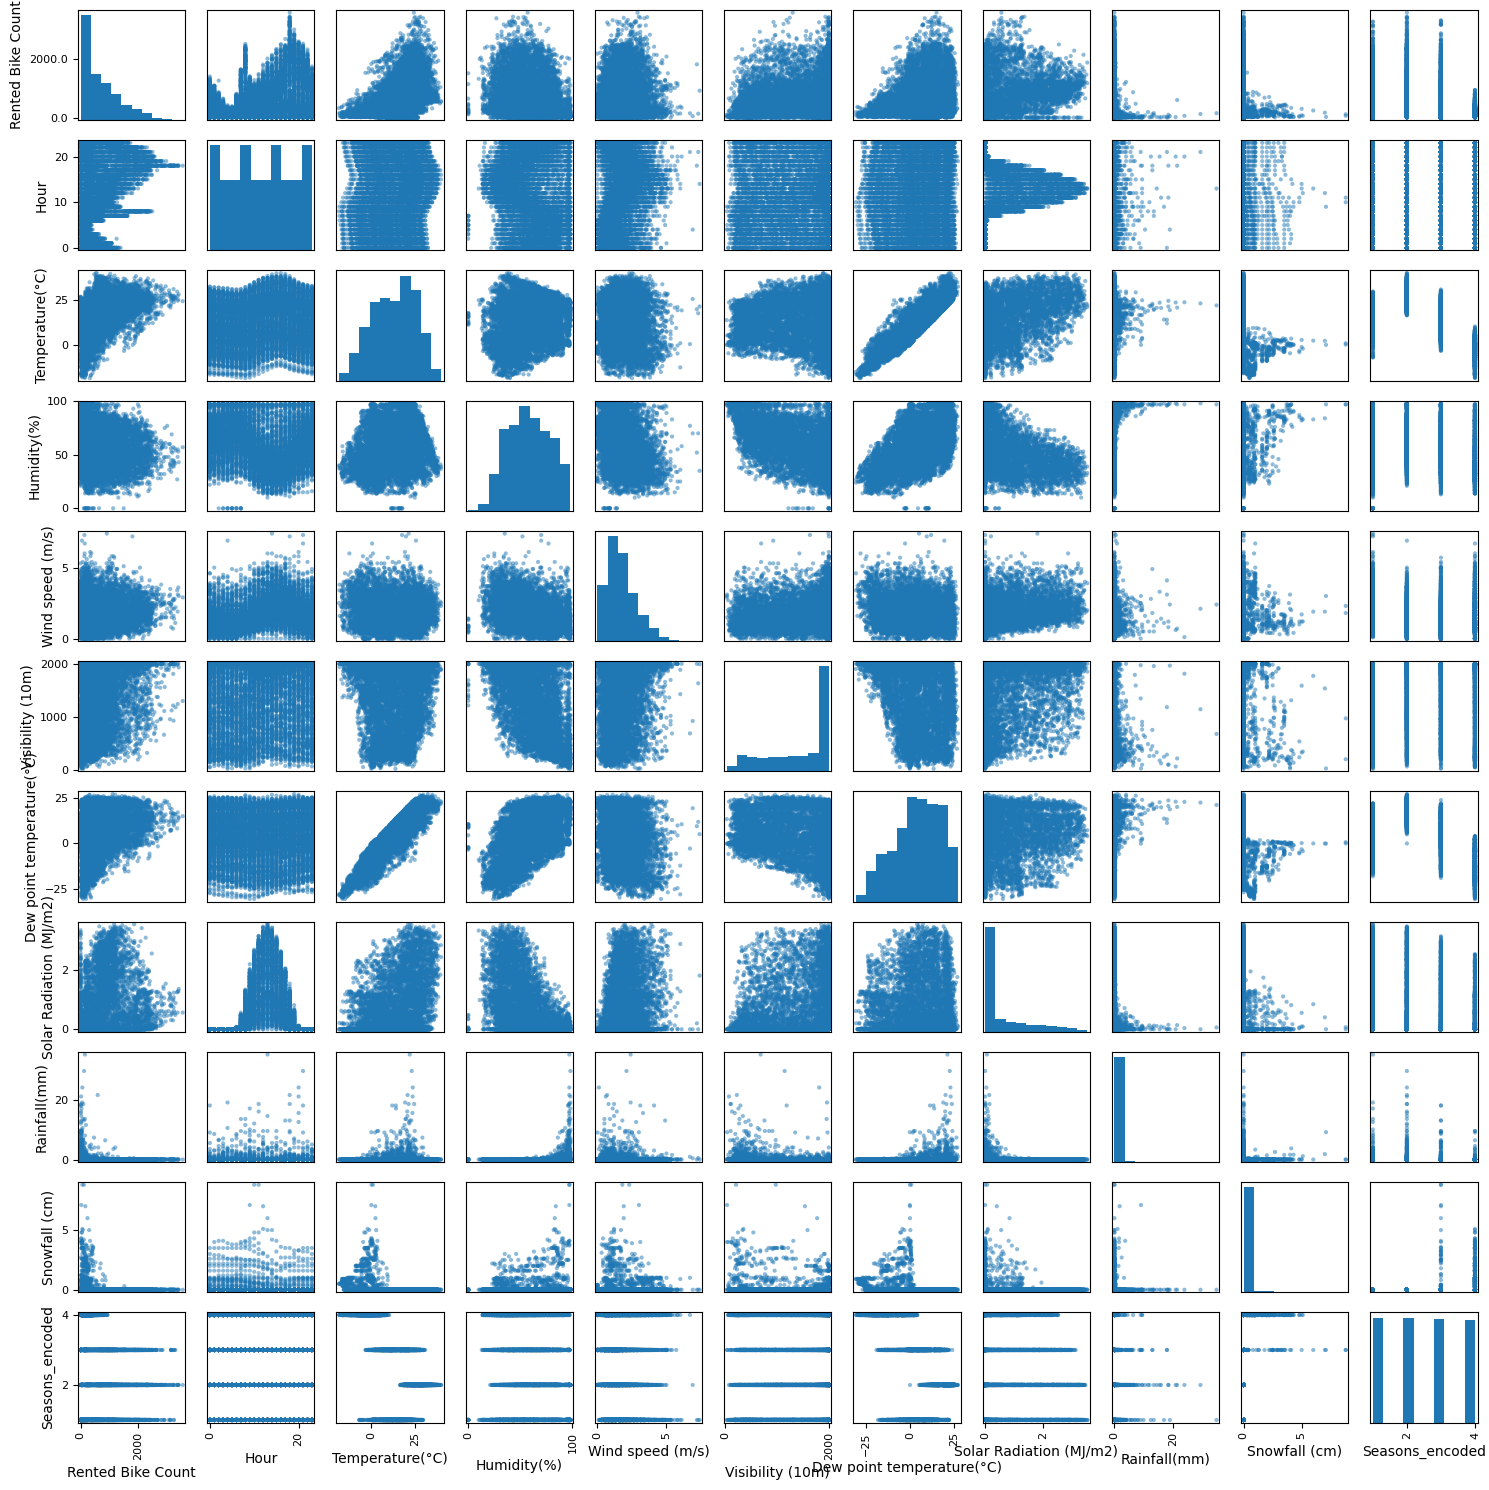

In [ ]:

numeric_data = data.drop(['Seasons','Holiday_encoded','Functionating_day_encoded'], axis=1)


axes = pd.plotting.scatter_matrix(numeric_data, figsize=(15, 15))


new_labels = [
    round(float(i.get_text()), 2) for i in axes[0, 0].get_yticklabels()
]
_ = axes[0, 0].set_yticklabels(new_labels)

plt.tight_layout()
plt.show()


**Bike Demand**
*  Hour - Bike rental demand strongly varies throughout the day. Peak usage occurs during commuting hours (morning and evening), while demand is much lower at night.
* Temperature - Warmer temperatures encourage cycling, leading to higher bike rentals. However, demand can decline during extremely cold or excessively hot conditions.
* Humidity - Both very low and very high humidity reduce bike demand. Moderate humidity levels provide more comfortable conditions, supporting higher rentals
* Wind speed - Increasing wind speed significantly decreases rentals. Strong winds make cycling more difficult and potentially unsafe
* Visibility - There is lower demand of bikes when there is worse visibility. Poor visibility (e.g., fog, heavy rain, or snow) lowers demand, as riders may feel less safe on the roads.
* Dew point temperature - A high dew point indicates humid, sticky conditions that discourage cycling, while moderate dew points correspond to comfortable weather that supports rentals. Dew point is strongly correlated with temperature, so while it may not add much new predictive value, it provides context for the combined effects of heat and humidity.
* Solar radiation – Solar radiation is positively associated with bike rental demand. Sunny conditions encourage outdoor activity, commuting, and recreation, leading to more rentals. The scatter matrix confirms this trend: higher solar radiation aligns with increased bike usage, while periods of low solar radiation, such as cloudy or rainy days, show lower rental counts.
* Rainfall and snowfall – both weather conditions show drastic decrease in bike renting count. It can be caused by uncomfortable environment; by such weather conditions, customers are less likely to make any outdoor activities      

**Summary**

The scatter matrix shows that bike rental demand is strongly influenced by both time and weather conditions. Rentals peak during commuting hours and in warmer, sunnier weather. Favorable conditions such as moderate temperature, humidity, visibility, and solar radiation support higher demand. In contrast, extreme weather factors—including very high or low temperatures, high humidity, strong winds, poor visibility, rainfall, and snowfall—lead to sharp declines in rentals. Dew point temperature, closely related to air temperature, further reflects the combined impact of heat and humidity on cycling comfort. Overall, the analysis confirms that bike demand increases in safe, comfortable, and clear weather, while unfavorable or extreme conditions discourage rentals.

## Correlation matrix

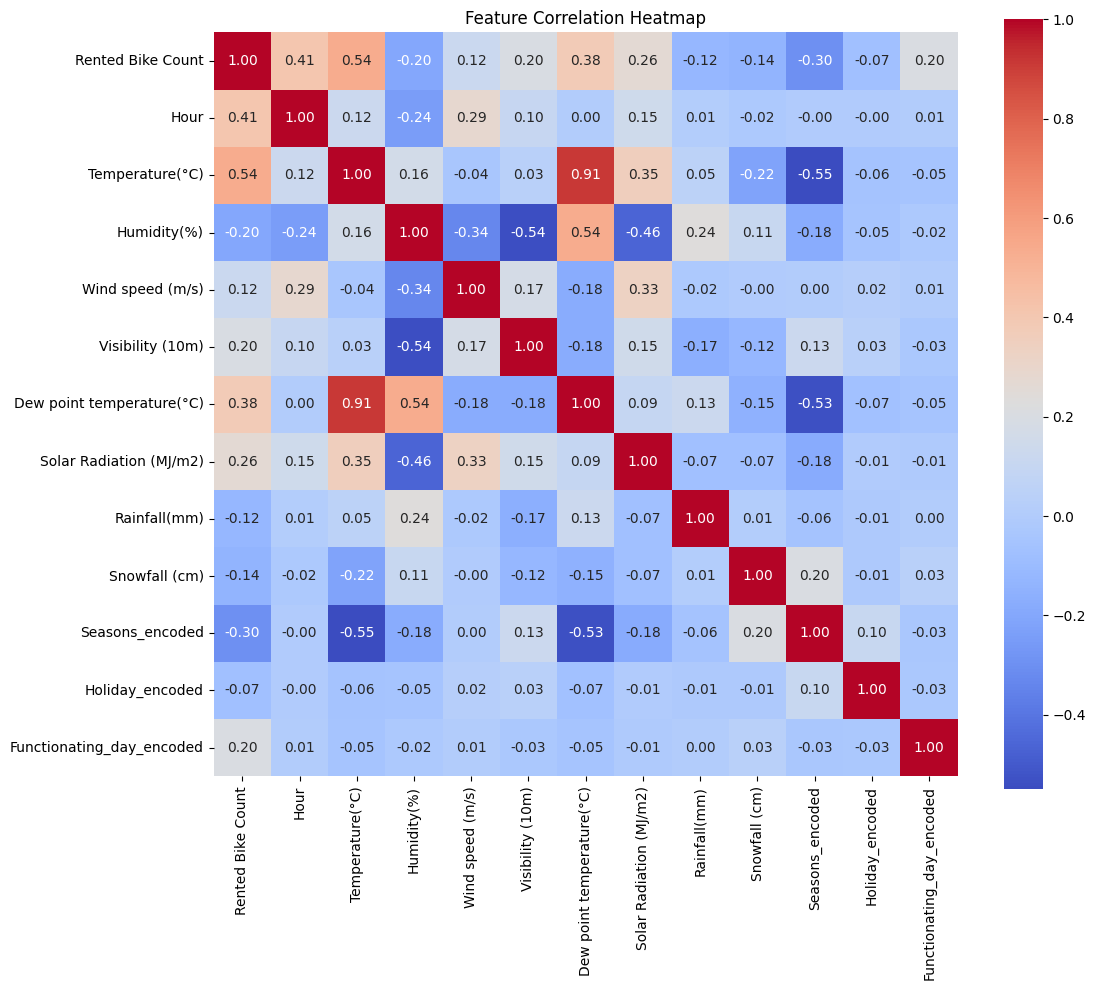

In [ ]:
# Calculate the correlation matrix
corr_matrix = data.corr(numeric_only=True) #numeric_only because otherwise I had problems with dates

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

Main correlations we can observe :
- Rented bikes increase as the hour of the day increases (0.41)
- Rented bikes decrease as the season increases (-0.30)
- Temperature decreases as the season increases (-0.55)
- Rented bikes increase as the temperature increases (0.41)
- Wind speed decreases as humidity increases (-0.34)
- Visibility decreases as humidity increases (-0.54)
- ... (see on the matrix)

Bike rental demand is positively associated with temperature, sunshine, and favorable visibility, while negatively affected by humidity, snowfall, and to a smaller degree, rainfall and wind speed. Temperature stands out as the most important weather predictor, but due to its strong correlation with dew point temperature and solar radiation, care should be taken to avoid multicollinearity in predictive models. Categorical features like season add context (e.g., fewer rentals in winter), while holidays have limited impact.

#Feature Extraction
The process of feature extraction is part of data analysis. It aims to analyse, which features are the most significant for training an accurate model. Reducing the number of features is to ease complexity of the model and decrease the calculations

## Subset selection

## Data preparation

In [ ]:
np.random.seed(333)
data_copy = data.copy()
data_copy = data_copy.drop(columns=['Date', 'Seasons'])

y = data_copy['Rented Bike Count']
X = data_copy.drop(columns=['Rented Bike Count'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=333)

Before training our models, we need to prepare the data:

`np.random.seed(333)` ensure that the random process (i.e. for data splitting) will produce the same result each time we run the code. Thus, our analysis can be done again and again in the same conditions to be verified.

We create a copy of the data and remove unwanted/redundant columns. Then we separate our target (y: Rented Bike Count) and the features we will use for the predictions.

Finally we proceed to the train-test split (75% / 25%) using the appropriate function.

## Data normalization

In [ ]:
mu = X_train.mean()
sigma = X_train.std()

X_train = (X_train-mu)/sigma
X_test = (X_test-mu)/sigma

Data normalization ensure that all features contribute equally to the model training process. Here is the formula applied to obtain a mean of 0 and a standard deviation of 1 (in case of normal distribution).

$$Z = \dfrac{X - \mu}{\sigma}$$

This helps improve the convergence of optimization algorithms used in training models like linear regression.

We need to implement the normalization after the splitting between train and test to avois data leak, using the mean of the whole dataset for example.

##Recursive Feature Elimination

Recursive Feature Elimination (RFE) is a feature selection method that works by repeatedly removing attributes and building a model based on the remaining attributes. The model's performance (often measured by metrics like Mean Squared Error or accuracy) is used to identify the most important attributes (and combinations of attributes) for predicting the target variable.

This method trains the model with a selected number of features, ranks their importance, and then eliminates the least important features. This technique is repeated, with the model being retrained on the reduced set of features at each step, until the desired number of features is reached or the model shows optimal results with a minimal set of variables.

In [ ]:
models = {

    "Linear Regression": LinearRegression(),
    "Ridge(alpha=0.01)": Ridge(alpha=0.01),
    "Lasso(alpha=0.01)": Lasso(alpha=0.01),
    "ElasticNet(alpha=0.01)": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
}

This code aims to determine both the best model and the optimal number of features for an accurate prediction. We test each model above with every possible number of features. This creates a complete picture of how each model performs as we vary the feature count. This process is performant in term of result but ressource intensive.

In [ ]:
results = []

for model_name, model in models.items():
    for features_number in range(X.shape[1], 0, -1):
        pipe = Pipeline([
            ('rfe', RFE(estimator=model, n_features_to_select=features_number)),
            ('model', model)])

        scores = cross_val_score(pipe, X_train, y_train, cv=5,scoring="neg_mean_squared_error")

        results.append({
            "Model": model_name,
            "Features_Count": features_number,
            "CV_MSE_mean": -scores.mean(),
            "CV_MSE_std": scores.std()
        })

results_df = pd.DataFrame(results).sort_values(by='CV_MSE_mean')

For each combination of model and feature count, we create a pipeline that:

1.   Uses RFE to select the specified number of most important features
2.   Trains the model using only those selected features

To avoid misleading results, we use 5-fold cross-validation instead of training once (the model is trained 5 times, each time using 4 parts for training and 1 for validation). We apply cross-validation with the entire pipeline (feature selection + model training) to prevent data leakage. It means RFE is performed independently within each fold (ressource intensive).

We use Mean Squared Error (MSE) as our evaluation metric.

###Plots

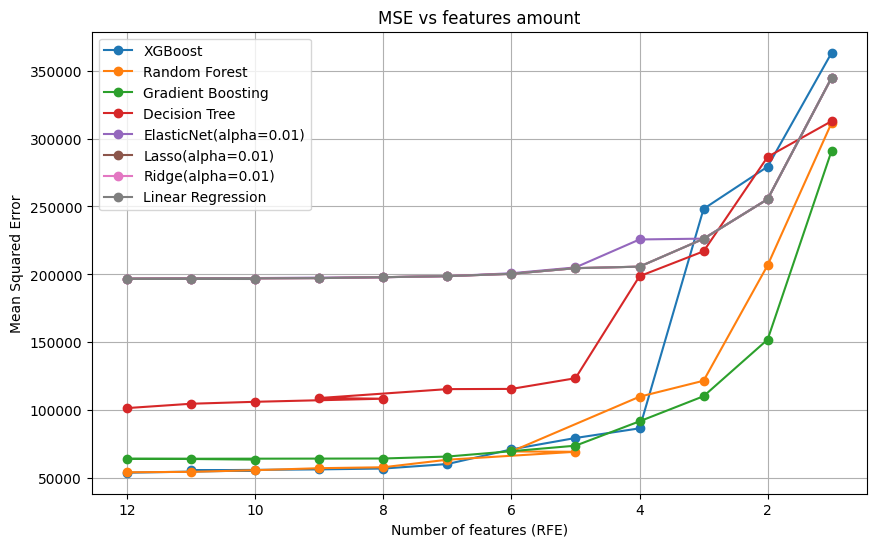

In [ ]:
plt.figure(figsize=(10, 6))

for model_name in results_df['Model'].unique():
    subset = results_df[results_df['Model'] == model_name]
    plt.plot(subset['Features_Count'], subset['CV_MSE_mean'], marker='o', label=model_name)

plt.gca().invert_xaxis()
plt.title("MSE vs features amount")
plt.xlabel("Number of features (RFE)")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

pd.set_option('display.max_colwidth', None)

The results show that the best models for our dataset are XGBoost, Random Forest and Gradient Boosting. This result is not surprising since these three models have common characteristics. All are ensemble methods that combine multiple decision trees, really suitable to capture non-linear relationships:

*   Random Forest builds many independent trees in parallel and take the average of their predictions
*   Gradient Boosting builds trees one after the other, correcting the errors of the previous one
*   XGBoost is an optimized version of gradient boosting with additional regularization

In contrast, the linear regression but also Lasso and ElasticNet showed the worst performance. These linear models with regularization struggle because bike rental demand has complex, non-linear patterns that cannot be predicted by linear combinations of features.

All results are stored in a dataframe and sorted by MSE. Thus we can identify which model and which number of features perform best:

In [ ]:
display(results_df)

,Model,Features_Count,CV_MSE_mean,CV_MSE_std
84,XGBoost,12,54061.350000,2887.684610
60,Random Forest,12,54385.681845,4253.967721
61,Random Forest,11,54711.472010,4045.511063
86,XGBoost,10,55738.789062,2702.138169
85,XGBoost,11,55806.083594,4043.723231
...,...,...,...,...
47,ElasticNet(alpha=0.01),1,344847.282953,31045.301858
35,Lasso(alpha=0.01),1,344848.660589,31075.799107
23,Ridge(alpha=0.01),1,344848.701292,31075.996367
11,Linear Regression,1,344848.702526,31076.007865


XGBoost has the lowest MSE (54061 using 12 features), followed closely by Random Forest (54386). Both models outperform Gradient Boosting with a best result around 63697 MSE (~ 18% worse than XGBoost).

All of them perform best between 7 and 12 features (performance drops below 5 features). It suggests that most variables are important for prediction.

Overall XGBoost is the most consistent across cross-validation folds (~ 2900 std vs ~ 4000 for Random Forest). Then we can conclude that XGBoost is more reliable.

Number of features selection is a tradee-off between model complexity and performance:

* XGBoost: 7 features: Reduces complexity by 42% while increasing
error by only 11.8%.

* Random Forest: 7 features: Performance is similar to XGBoost. The same number is used to compare the models.

* Gradient Boosting: 6 features: Shows stable performance across 6-12 features. 6 features reduces complexity with only 9.7% higher error than optimal.

In [ ]:
best_n = {RandomForestRegressor(n_estimators=100, random_state=42):7,
    GradientBoostingRegressor(n_estimators=100, random_state=42):6,
    XGBRegressor(objective='reg:squarederror', random_state=42):7}

dict_selected_features = {}

for m,b in best_n.items():
  pipe_final = Pipeline([
      ('rfe', RFE(estimator=m, n_features_to_select=b)),
      ('model', m)
  ])
  pipe_final.fit(X_train, y_train)
  selected_features = X_train.columns[pipe_final.named_steps['rfe'].support_]
  dict_selected_features[m] = selected_features

After determining the optimal number of features for our three best models (XGBoost: 7, Random Forest: 7, Gradient Boosting: 6) we need to identify which features each model selected. For each model, we fit the training data again and extract the selected feature names using the `support_` attribute.

In [ ]:
dict_selected_features

{RandomForestRegressor(random_state=42): Index(['Hour', 'Temperature(°C)', 'Humidity(%)', 'Dew point temperature(°C)',
        'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Functionating_day_encoded'],
       dtype='object'),
 GradientBoostingRegressor(random_state=42): Index(['Hour', 'Temperature(°C)', 'Humidity(%)', 'Solar Radiation (MJ/m2)',
        'Rainfall(mm)', 'Functionating_day_encoded'],
       dtype='object'),
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_le

#Models

## XGBoost

XGBoost (Extreme Gradient Boosting) is an optimized implementation of gradient boosting. It proceeds by building decision trees one after the other. Each new tree corrects the errors made by the previous one. XGBoost's advantage is to include regularization (to prevent overfitting but also model complexity for example). This is good with complex, non-linear relationships like in our bike-sharing dataset.

We initialize the XGBoost model with `reg:squarederror` as the objective function to minimizes mean squared error. We then re-apply RFE to get the 7 most important features from the training data and create a reduced datasets (X_train_sel and X_test_sel).

In [ ]:
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

features_number = 7
rfe = RFE(estimator=xgb_model, n_features_to_select=features_number)
rfe.fit(X_train, y_train)
selected_features = X.columns[rfe.support_]

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

### Hyperparameters tuning

Now we can perform some hyperparameters tuning. The point is to improve our model as much as possible taking the best out of the parameters we can tune in it. Thus, before training the model out of fold, we will evaluate performance with selected features and tuned parameters.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, #to allocate more resources during the execution (quicker)
)

grid_search.fit(X_train_sel, y_train)
best_xgb = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


We chose among the common parameters available and make them vary around the default value. Then we obtain the best set of parameters. This grid search method is quite resource intensive as it tests all possibilities, consequently we can't test with too many values for each parameter.

*   `n_estimators`: Number of trees. Too many trees means overfitting while not enough trees leads to underfitting.
*   `max_depth`: Maximum depth of each tree. Higher values lead to more complexity and potential overfitting. However, our range of values ([3, 5, 7]) is reasonable according to various resources and documentation.
*   `learning_rate` (or eta): How much each step (tree) contributes to the final prediction. The lower this parameter the best because it allows better generalization even if it is quite resource intensive.
*   `subsample`: Fraction of training data used for each tree. Using a value lower than 1 introduces randomness (which can prevent overfitting). However we didn't want to go for to small values to avoid the opposit pitfall.
*   `colsample_bytree`: Fraction of features (columns) used for each tree. Like `subsample`, it permits randomness and can improve generalization.

### Out-of-fold prediction

Finally, we train the XGBoost model with the selected features and parameters and then do the prediction out of fold for the model evaluation. The MSE is 11.2% lower with the tuned parameters.

In [ ]:
y_train_pred = cross_val_predict(xgb_model, X_train_sel, y_train, cv=5)
y_train_pred_best = cross_val_predict(best_xgb, X_train_sel, y_train, cv=5)

mse = mean_squared_error(y_train, y_train_pred)
mse_best = mean_squared_error(y_train, y_train_pred_best)
print(f"XGBoost model - MSE: {mse} ; XGBoost model with best hyperparameters - MSE: {mse_best}")

XGBoost model - MSE: 70287.7109375 ; XGBoost model with best hyperparameters - MSE: 62398.2578125


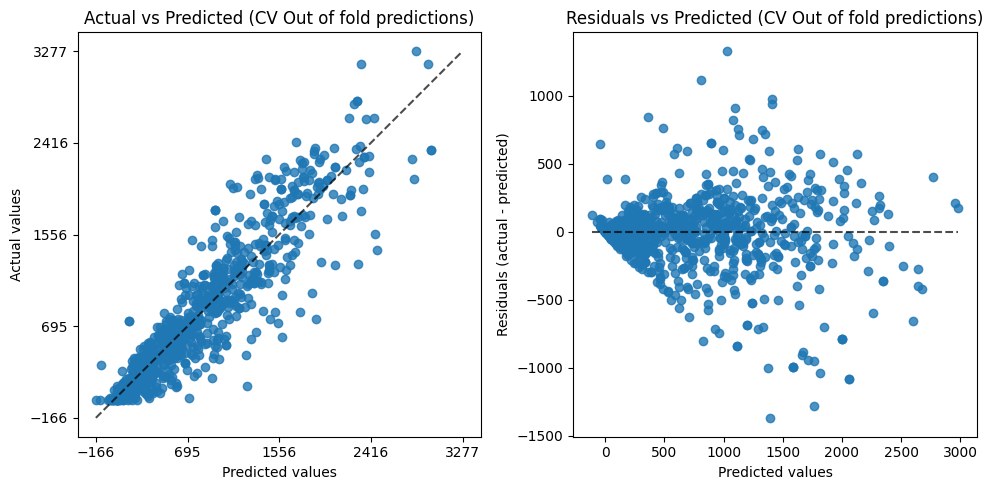

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

PredictionErrorDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_train_pred_best,
    kind="actual_vs_predicted",
    ax=axs[0],
)

PredictionErrorDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_train_pred_best,
    kind="residual_vs_predicted",
    ax=axs[1],
)

axs[0].set_title("Actual vs Predicted (CV Out of fold predictions)")
axs[1].set_title("Residuals vs Predicted (CV Out of fold predictions)")

plt.tight_layout()
plt.show()

The actual vs predicted plot shows a really good alignment with the diagonal line showing the model’s good performance for predicting with our dataset. This is true all across the range of values. We can assume that XGBoost can deal with the shape of our data (both typical and peak rental).

The residual plot further confirms the model’s robustness, with residuals quite evenly distributed around the zero line. There is no sign of any systematic patterns in the errors.

### Final prediction

Now we finally need to test our model on the unseen data from the test split.

In [ ]:
xgb_model.fit(X_train_sel, y_train) #train XGB
y_test_pred = xgb_model.predict(X_test_sel)

best_xgb.fit(X_train_sel, y_train) #train XGB with best hyperparameters
y_test_pred_best = best_xgb.predict(X_test_sel)

mse = mean_squared_error(y_test, y_test_pred)
mse_best = mean_squared_error(y_test, y_test_pred_best)
print(f"XGBoost model - MSE: {mse} ; XGBoost model with best hyperparameters - MSE: {mse_best}")

XGBoost model - MSE: 70990.9765625 ; XGBoost model with best hyperparameters - MSE: 65529.94921875
XGBoost model with best hyperparameters - STD: 255.98656962822852


Prediction is performed and we finally obtain an MSE of ~ 70991 against ~ 70288 on the training data during the prediction out-of-fold with the simple model. This result corresponds to a small difference of ~ 1%. With the tuned model with parameters we obtain an MSE of ~ 65530 against ~ 62398 during the prediction out of fold. Again the difference is correct (~ 5%). Then we plot for the best model with tuned parameters:

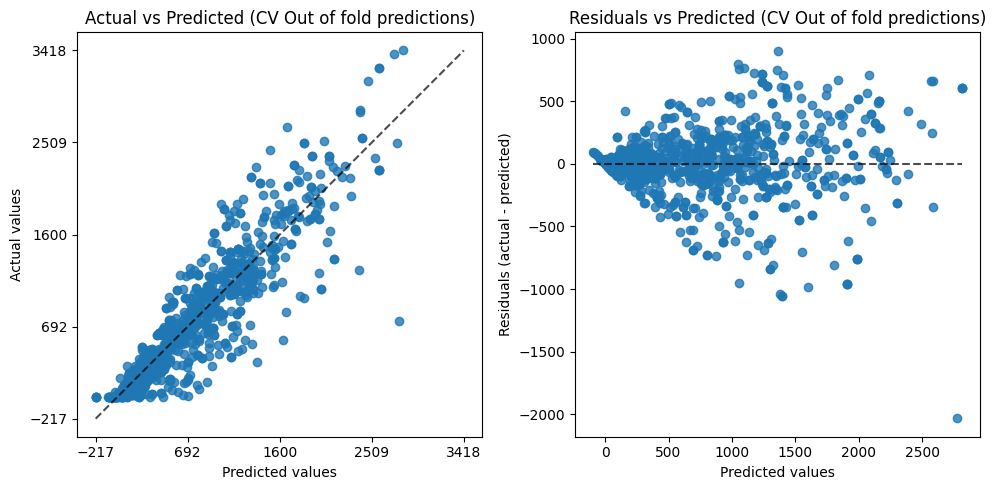

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_test_pred_best,
    kind="actual_vs_predicted",
    ax=axs[0],
)

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_test_pred_best,
    kind="residual_vs_predicted",
    ax=axs[1],
)

axs[0].set_title("Actual vs Predicted (CV Out of fold predictions)")
axs[1].set_title("Residuals vs Predicted (CV Out of fold predictions)")

plt.tight_layout()
plt.show()

We can observe the same shapes as in the evaluation out-of-fold on the training data leading to the same conclusions.

## Random Forest

Random Forest Regression is an ensemble learning method that constructs multiple decision trees during training. For regression tasks, it combines the predictions of all individual decision trees by averaging their outputs. This approach helps to reduce overfitting and improve the predictive accuracy and robustness of the model compared to a single decision tree.

To clarify the difference: Random Forest differs from XGBoost in that it builds many independent decision trees in parallel and averages their predictions, whereas XGBoost builds trees sequentially, with each new tree correcting the errors of the previous ones.

Random Forest evaluates performance by combining the predictions of independent trees using averaging for regression tasks (and majority voting for classification tasks). Each tree contributes equally to the final prediction. XGBoost, in contrast, produces predictions as a weighted sum of all trees, where trees are added sequentially and each new tree focuses on correcting the errors of the previous ones.

As a result, Random Forest is generally more robust to noise, while XGBoost is often better at capturing complex patterns through its boosting strategy.

### Feature selection

This code performs feature selection using Recursive Feature Elimination (RFE) with a RandomForestRegressor as the estimator. It identifies the 7 most important features from the training data (`X_train`) and then creates new datasets (`X_train_sel`, `X_test_sel`) containing only these selected features.

Parameters of the Random Forrest: <br>
`n_estimators=100`: This creates 100 individual decision trees that will work together; generally, more trees improve accuracy and stability but require more memory and time.

`random_state=42`: This is a seed for the random number generator, ensuring that your results are reproducible.

`n_jobs=-1`: This defines to use all available processors of the CPU to train the trees in parallel, significantly speeding up the computation.

In [ ]:
features_number = 7
rfr_estimator = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rfe = RFE(estimator=rfr_estimator, n_features_to_select=features_number)
rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]
print(f"Selected features for Random Forest: {list(selected_features)}")

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

Selected features for Random Forest: ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Functionating_day_encoded']


### Hyperparameter Tuning

This cell performs hyperparameter tuning for the RandomForestRegressor using GridSearchCV. It defines a `param_grid` with different values for `n_estimators`, `max_depth`, and `min_samples_leaf`.

`n_estimators`: The number of individual trees in the forest. More trees generally improve accuracy but increase training time.

`max_depth`: The maximum height of each tree. Limiting this prevents the model from becoming too complex and memorizing noise (overfitting). `None` allows trees to grow until all leaves are pure or contain fewer samples than the min_samples_leaf threshold, providing the model maximum flexibility at the risk of overfitting.

`min_samples_leaf`: The minimum number of data points allowed in a "leaf" (end node). Larger values smooth the model and prevent it from making decisions based on just one or two outliers.

GridSearchCV systematically searches through these parameter combinations using 5-fold cross-validation to find the set of hyperparameters that yields the best performance (minimizing negative mean squared error). The `best_rfr` variable stores the model with the optimal parameters.

GridSearch parameters: <br>
`estimator`: The model being tuned (Random Forest), which acts as the base template for all tests.

`param_grid`: The list of hyperparameter values to test; it tries every possible combination of these values.

`cv=5`: 5-Fold Cross-Validation, which splits the data into 5 parts to ensure the model's performance is consistent across different subsets of data.

`scoring='neg_mean_squared_error'`: The metric used to evaluate the models, where a value closer to zero indicates a more accurate prediction.

`n_jobs=-1`: A performance boost that runs the different model tests simultaneously using all processors.

`verbose=1`: Print out status updates.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_sel, y_train)
best_rfr = grid_search_rf.best_estimator_
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest: {'max_depth': 30, 'min_samples_leaf': 4, 'n_estimators': 200}


### Training

This code generates out-of-fold predictions on the training data using the `best_rfr` model (the RandomForestRegressor with optimized hyperparameters). `cross_val_predict` ensures that each prediction is made by a model that has not seen the data point during its training phase within the cross-validation folds, providing a more robust estimate of the model's performance on unseen data.

In [ ]:
y_train_pred_rfr_cv_best = cross_val_predict(best_rfr, X_train_sel, y_train, cv=5, n_jobs=-1)

These plots visualize the performance of the tuned Random Forest model on the training data (using the out-of-fold predictions). The 'Actual vs Predicted' plot shows how well the model's predictions align with the true values. The 'Residuals vs Predicted' plot helps to identify any systematic errors or patterns in the residuals (the differences between actual and predicted values), indicating potential biases or areas where the model might be struggling.

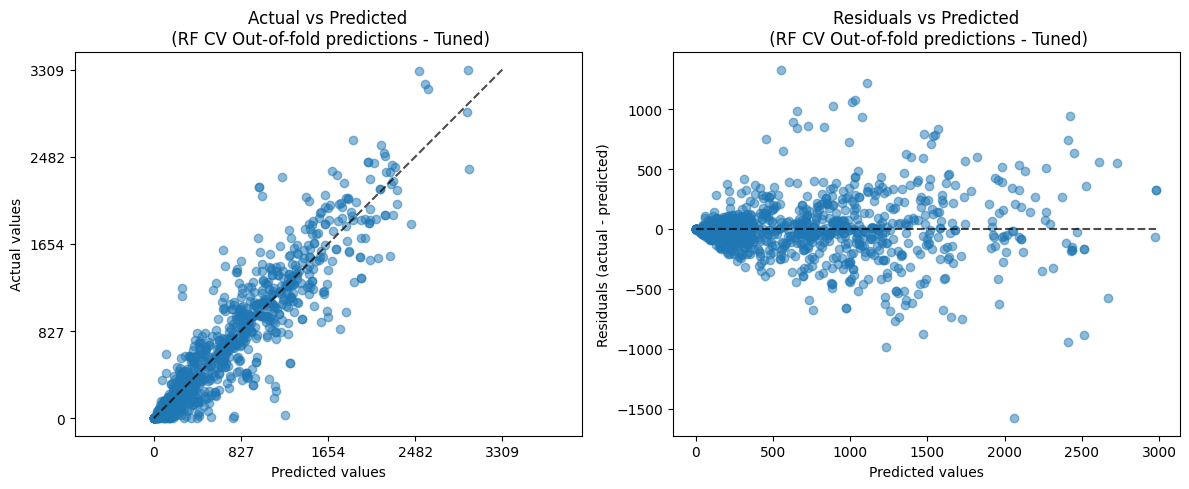

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

PredictionErrorDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_train_pred_rfr_cv_best,
    kind="actual_vs_predicted",
    ax=axs[0],
    scatter_kwargs={'alpha': 0.5}
)

PredictionErrorDisplay.from_predictions(
    y_true=y_train,
    y_pred=y_train_pred_rfr_cv_best,
    kind="residual_vs_predicted",
    ax=axs[1],
    scatter_kwargs={'alpha': 0.5}
)

axs[0].set_title("Actual vs Predicted\n (RF CV Out-of-fold predictions - Tuned)")
axs[1].set_title("Residuals vs Predicted\n (RF CV Out-of-fold predictions - Tuned)")

plt.tight_layout()
plt.show()


This cell trains the final `best_rfr` model (with optimized hyperparameters) on the entire selected training dataset (`X_train_sel` and `y_train`). After training, it makes predictions on the unseen test dataset (`X_test_sel`) to evaluate the model's generalization capability.

In [ ]:
best_rfr.fit(X_train_sel, y_train)

y_test_pred_rfr_tuned = best_rfr.predict(X_test_sel)

### Testing

This code evaluates the performance of the final tuned Random Forest model on the test set using Mean Squared Error (MSE) and R-squared (R2). It then generates two plots: an 'Actual vs Predicted' plot to visually assess the model's accuracy on unseen data and a 'Residual Plot' to inspect the distribution of prediction errors, helping to confirm the model's robustness and lack of systematic bias.


Random Forest Regression (Tuned with RFE) - MSE: 66620.2708
Random Forest Regression (Tuned with RFE) - R²: 0.8384


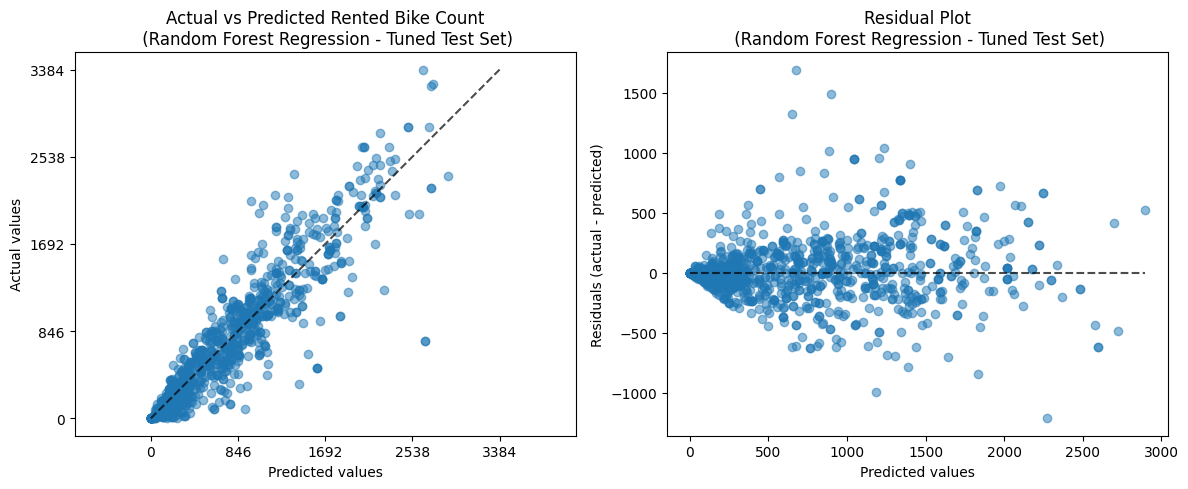

In [ ]:

mse_rfr_tuned = mean_squared_error(y_test, y_test_pred_rfr_tuned)
r2_rfr_tuned = r2_score(y_test, y_test_pred_rfr_tuned)

print(f"\nRandom Forest Regression (Tuned with RFE) - MSE: {mse_rfr_tuned:.4f}")
print(f"Random Forest Regression (Tuned with RFE) - R²: {r2_rfr_tuned:.4f}")

fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_test_pred_rfr_tuned,
    kind="actual_vs_predicted",
    ax=axs[0],
    scatter_kwargs={'alpha': 0.5}
)

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_test_pred_rfr_tuned,
    kind="residual_vs_predicted",
    ax=axs[1],
    scatter_kwargs={'alpha': 0.5}
)

axs[0].set_title("Actual vs Predicted Rented Bike Count\n (Random Forest Regression - Tuned Test Set)")
axs[1].set_title("Residual Plot\n (Random Forest Regression - Tuned Test Set)")

plt.tight_layout()
plt.show()

The tuned Random Forest model achieved an MSE of approximately **66620.27** and an R-squared of **0.8384** on the unseen test data. Comparing this to the XGBoost model's test MSE of approximately **65529.95**, Random Forest performs very similarly, with XGBoost having a slightly lower (better) MSE.

Both models demonstrate strong predictive capabilities for bike rental demand, accurately capturing a significant portion of the variance in the data, as indicated by the high R-squared values. The 'Actual vs Predicted' plot shows a good alignment of predictions with true values, while the residual plot indicates a relatively even distribution of errors around zero, suggesting the absence of major systematic biases. However, similar to XGBoost, there might be some increased scatter at higher rental counts, potentially due to fewer examples of such extreme values in the dataset.

##Neural Network
In this chapter, a neural network model was implemented and trained to predict the bike count based on the given input variables. Although the results obtained from previous machine learning models were already good and did not strictly require the use of a neural network, a deep learning approach was explored to potentially capture more complex, non-linear relationships in the data that traditional machine learning models might not detect.


###Neural Network Class

This NN class shows a built neural network model containing 4 layers, 3 of which are hidden. Each hidden layer contains Linear layer, Batch Normalization, LeakyReLU activation function, and Dropout function, with default value equal 0,3. This build provides complex analysis of input data to recognise advanced dependencies.

**nn.Linear** creates a fully connected layer in a neural network. Each neuron in the layer computes a weighted sum of its inputs followed by a bias term $
y_j = \sum_{i} x_i w_{ij} + b_j
$ where $x_i$ are the input features, $w_{ij}$ are the weights, and $b_j$ is the bias. The weights and biases are learned during training. In this model, the layers are arranged sequentially with a decreasing number of neurons, allowing the network to first capture a broad set of patterns with more neurons and then gradually refine and combine these features in subsequent layers to detect more complex dependencies.

**nn.BatchNorm1d** is a function that collects neurons outputs into *minibatch* and normalize them based on mean and standard deviation of the minibatch. The normalization process is calculated: $$\hat{x}_{i} = \frac{x_{i} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$ where $\mu_B$ is mean of minibatch, $\sigma_B^2$ is its variance, and $\epsilon$ is a small number added for numerical stability. After normalization, a linear transformation is applied: $
\hat{y}_j = \sum_{i} \hat{x}_i \gamma_{ij} + \beta_j
$m where $\gamma$ and $\beta$ are learnable parameters that allow the network to scale and shift the normalized outputs.

**nn.LeakyReLU** is an activation function similar to the ReLU activation function. ReLU sets outputs to zero for negative input values, therefore has a zero gradient in this region. LeakyReLU allows a small, non-zero gradient for negative inputs. This behavior helps prevent the problem, where neurons stop learning because their gradients become zero.
LeakyReLU is defined as:$$
f(x) =
\begin{cases}
x, & x \ge 0 \\
\alpha x, & x < 0
\end{cases}
$$

where $\alpha$ is a small constant (in this project $0.01$) that controls the slope for negative input values.

**nn.Dropout** is a function that randomly disactivates certain number of neurons during training to prevent overfitting. In this project, the default dropout rate is set to 0.3, which means that 30% of neurons are deactivated in the process.

In [ ]:
class NN(nn.Module):
    def __init__(self, n_features, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            #first layer
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),
            #second layer
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),

            #third layer
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),
            # fourth (the last) layer
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

####Data Preparation
Correct data preparation is crucial for a neural network model to learn effectively and produce reliable results. It is also important to separate the data into training, validation, and testing datasets to prevent data leakage, which could otherwise lead to overly optimistic performance estimates.

To properly prepare the data, first they were separated into six groups – X_train, y_train, X_val, y_val, X_test, y_test.
- X_train, X_val, X_test - contains separated features for each part of the training.
- y_train, y_val, y_test - contains separated target data corresponding to the features.

Secondly, to ensure that the model to recognises patterns in the data correctly, the feature data were scaled using StandardScaler() function.
After that, all data are transferred into tensor format due to Pytorch model working correctly on tensors.
Finally, the data are segmented into dataloader to properly connect features and target data for the model

In [ ]:
np.random.seed(333)
data_copy = data.copy()
data_copy = data_copy.drop(columns=['Date', 'Seasons'])
y = data_copy['Rented Bike Count'].values.reshape(-1, 1)
X = data_copy.drop(columns=['Rented Bike Count']).values
n_features = X.shape[1]

# Data split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=333, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=333, shuffle=True
)

# Scaling
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Dataloader
BATCH_SIZE = 64
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


###Hyperparameter tuning
This technique helps identify the best combination of hyperparameters to achieve optimal model performance. For the neural network model, the *optuna* library was used as a tool for automated hyperparameter optimization.


In [ ]:
!pip install optuna

A function to train and validate for hyperparameter tuning. The final evaluation is based on test data, used after training.

In [ ]:
def train_and_validate(model, optimizer, criterion, train_dataloader, val_dataloader, test_dataloader, epochs):

  for epoch in range(epochs):
        # TRAIN
        model.train()
        running_train_loss = 0.0
        for X_batch, y_batch in train_dataloader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)
        # avg_train_loss = running_train_loss / len(train_dataloader.dataset)

        # VALIDATION
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_val_batch, y_val_batch in val_dataloader:
                y_pred_val = model(X_val_batch)
                val_loss = criterion(y_pred_val, y_val_batch)
                running_val_loss += val_loss.item() * X_val_batch.size(0)
        avg_val_loss = running_val_loss / len(val_dataloader.dataset)
        # print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
      # TEST
  model.eval()
  running_test_loss = 0.0
  y_true_scaled_list = []
  y_pred_scaled_list = []
  with torch.no_grad():
    for X_test, y_test in test_dataloader:
      y_pred_test = model(X_test)
      test_loss = criterion(y_pred_test, y_test)

      y_true_scaled_list.append(y_test.cpu().numpy())
      y_pred_scaled_list.append(y_pred_test.cpu().numpy())

      running_test_loss += test_loss.item() * X_test.size(0)

  final_test_mse = running_test_loss / len(test_dataloader.dataset)

  y_true_np = np.vstack(y_true_scaled_list)
  y_pred_np = np.vstack(y_pred_scaled_list)
  r2 = r2_score(y_true_np, y_pred_np)

  print(f"MSE: {final_test_mse:.4f}\n")

  return final_test_mse, r2


**import optuna** is an automated hyperparameter optimization framework that efficiently searches for optimal model configurations to improve performance.

In this project, there are five hyperparameters that are modified: learning rate, dropout value, batch size, epoch amount and optimizer.

The *objective* function defines the hyperparameters to be optimized, trains the model using these parameters, and returns a performance metric that reflects the model’s results for a given hyperparameter configuration.


**Learning rate** controls the step size of parameter updates during training. If it is too large, training becomes unstable or diverges; if it is too small, learning becomes very slow or may get stuck.

**Batch size** is the number of samples used to compute one gradient update. Smaller batch sizes produce noisier gradients but often lead to better generalization.

**Epochs** represent the number of full passes over the training dataset. Too few epochs can cause underfitting, while too many can lead to overfitting.

**Optimizer** defines how a neural network updates its weights using computed gradients. It influences learning speed, stability, and overall performance by controlling how gradients are applied during training.

In [ ]:
import optuna


def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout_rate", 0.0, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])
    epochs = trial.suggest_int("epochs", 20, 60)

    optimizer_name = trial.suggest_categorical(
        "optimizer", ["Adam", "AdamW", "RMSprop"]
    )

    model = NN(n_features, dropout_rate=dropout)

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)


    criterion = nn.MSELoss()

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    test_loss, test_r2 = train_and_validate(
        model,
        optimizer,
        criterion,
        train_dataloader,
        val_dataloader,
        test_dataloader,
        epochs
    )

    return -test_r2


The number of trials was set to 150, meaning that 150 models were trained using different hyperparameter configurations. During the optimization process, the objective function identifies the best-performing configuration based on the selected evaluation metric, which in this case is $-R^2$. This measurement evaluation is used because the optimisation process is formulated as a minimisation problem.

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=150)

print("BEST:", study.best_params)


[I 2025-12-14 11:40:12,211] A new study created in memory with name: no-name-01aace2e-8d8c-4268-8c2e-e489206fe848
[I 2025-12-14 11:40:36,021] Trial 0 finished with value: 1.0514633655548096 and parameters: {'lr': 0.00012572172392053232, 'dropout_rate': 0.15279031273728932, 'batch_size': 64, 'epochs': 58, 'optimizer': 'Adam'}. Best is trial 0 with value: 1.0514633655548096.


MSE: 803701.3213



[I 2025-12-14 11:40:56,266] Trial 1 finished with value: 1.1277062892913818 and parameters: {'lr': 5.7963621371257705e-05, 'dropout_rate': 0.4006236221020761, 'batch_size': 16, 'epochs': 23, 'optimizer': 'Adam'}. Best is trial 0 with value: 1.0514633655548096.


MSE: 833571.0360



[I 2025-12-14 11:42:06,320] Trial 2 finished with value: -0.6607083082199097 and parameters: {'lr': 0.000844127008355753, 'dropout_rate': 0.4006397881220365, 'batch_size': 8, 'epochs': 31, 'optimizer': 'AdamW'}. Best is trial 2 with value: -0.6607083082199097.


...

MSE: 79001.8006



[I 2025-12-14 12:28:21,865] Trial 148 finished with value: -0.8164209723472595 and parameters: {'lr': 0.001476250483000511, 'dropout_rate': 0.010500049371837848, 'batch_size': 64, 'epochs': 56, 'optimizer': 'Adam'}. Best is trial 133 with value: -0.8462097644805908.


MSE: 71920.7174



[I 2025-12-14 12:29:45,156] Trial 149 finished with value: -0.7177534103393555 and parameters: {'lr': 0.0018928271079138594, 'dropout_rate': 0.03365919486558079, 'batch_size': 8, 'epochs': 55, 'optimizer': 'Adam'}. Best is trial 133 with value: -0.8462097644805908.


MSE: 110575.6911

BEST: {'lr': 0.003739593693252939, 'dropout_rate': 0.00979042955937734, 'batch_size': 64, 'epochs': 54, 'optimizer': 'Adam'}


The optimization results indicate that the best hyperparameter combination for the current model is:

learning rate - 0.003739593693252939

drupout - 0.00979042955937734

batch size - 64

epochs - 54

optimizer - Adam

Using these parameters, the model achieved approximately $-R^2$ =  -0.8462 and MSE = 60250.35.
These hyperparameters were therefore selected for training the main model.

###Training
The main training and validation of the model uses the best combination of hyperparameters. It saves the loss of training and validation, to create a plot at the end.

In [ ]:
criterion = nn.MSELoss()
epochs = 55

model = NN(n_features,dropout_rate = 0.00979042955937734)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003739593693252939)

train_losses = []
val_losses = []

for epoch in range(epochs):
    # TRAIN
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_dataloader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    avg_train_loss = running_train_loss / len(train_dataloader.dataset)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_val, y_val in val_dataloader:
            y_pred_val = model(X_val)
            val_loss = criterion(y_pred_val, y_val)
            running_val_loss += val_loss.item() * X_val.size(0)

    avg_val_loss = running_val_loss / len(val_dataloader.dataset)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 000 | Train Loss: 912487.4357 | Val Loss: 916962.1347
Epoch 001 | Train Loss: 877680.9411 | Val Loss: 865277.7460
Epoch 002 | Train Loss: 804745.7610 | Val Loss: 770229.7460
Epoch 003 | Train Loss: 705086.9741 | Val Loss: 685911.6030
Epoch 004 | Train Loss: 589682.4908 | Val Loss: 545367.5478
Epoch 005 | Train Loss: 474926.0977 | Val Loss: 421785.4125
Epoch 006 | Train Loss: 364883.5043 | Val Loss: 339011.7213
Epoch 007 | Train Loss: 268899.0485 | Val Loss: 253256.4809
Epoch 008 | Train Loss: 200746.7354 | Val Loss: 180541.0618
Epoch 009 | Train Loss: 153075.2814 | Val Loss: 117670.1366
Epoch 010 | Train Loss: 125535.9922 | Val Loss: 114152.0104
Epoch 011 | Train Loss: 107880.1109 | Val Loss: 109022.1056
Epoch 012 | Train Loss: 94323.2559 | Val Loss: 104134.8100
Epoch 013 | Train Loss: 88298.3839 | Val Loss: 92602.4028
Epoch 014 | Train Loss: 87440.4850 | Val Loss: 88025.9768
Epoch 015 | Train Loss: 84644.7281 | Val Loss: 85170.3141
Epoch 016 | Train Loss: 84180.9137 | Val Loss: 

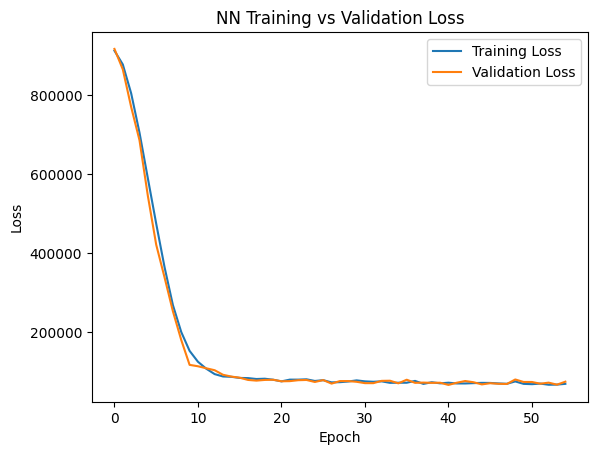

In [ ]:
#Creating the plots
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NN Training vs Validation Loss")
plt.legend()
plt.show()

###Test the model

In [ ]:
model.eval()
running_test_loss = 0.0
y_true_scaled_list = []
y_pred_scaled_list = []
with torch.no_grad():
    for X_test, y_test in test_dataloader:
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test)

        y_true_scaled_list.append(y_test.cpu().numpy())
        y_pred_scaled_list.append(y_pred_test.cpu().numpy())

        running_test_loss += test_loss.item() * X_test.size(0)

final_test_mse = running_test_loss / len(test_dataloader.dataset)

y_true_np = np.vstack(y_true_scaled_list)
y_pred_np = np.vstack(y_pred_scaled_list)
r2 = r2_score(y_true_np, y_pred_np)

print(f"\nFINAL TEST MSE: {final_test_mse:.4f}")
print(f"FINAL TEST R-squared: {r2:.4f}")


FINAL TEST MSE: 68016.6704
FINAL TEST R-squared: 0.8264


####Plots
Here are two plots, they are created based on test data.

Residual plot shows results of truth value minus value predicted by model (truth – prediction). In ideal case, all points supposed to be on red line.

The plot showing *Actual vs Predicted* shows values of predictions and compares them with true values for certain combination of features. In the best scenario, all points should lay on the black line.

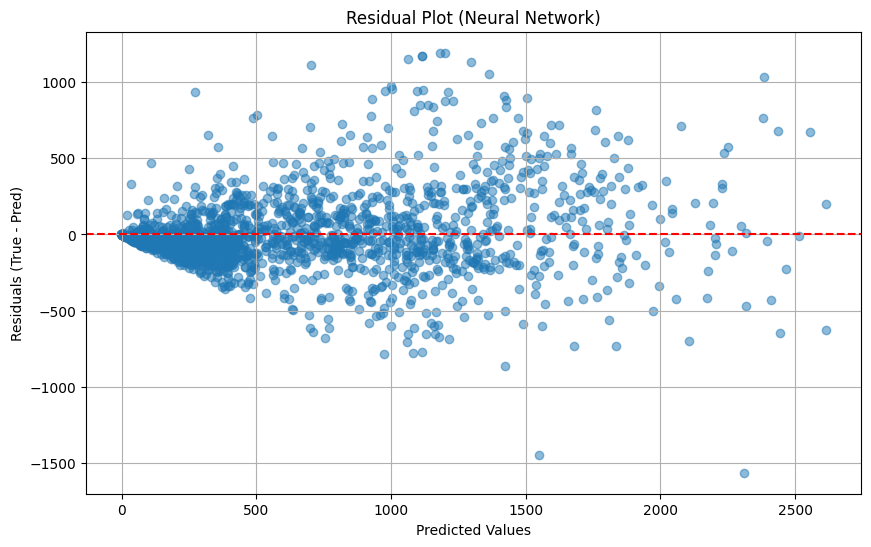

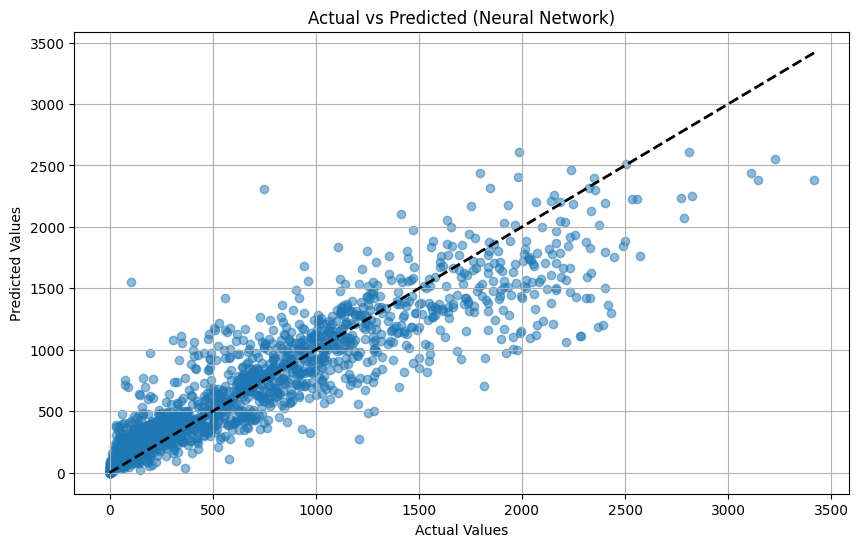

In [ ]:
all_y_true = []
all_y_pred = []

model.eval()
with torch.no_grad():
    for X_test_batch, y_test_batch in test_dataloader:
        y_pred_batch = model(X_test_batch)
        all_y_true.append(y_test_batch.numpy())
        all_y_pred.append(y_pred_batch.numpy())

y_true_np = np.vstack(all_y_true)
y_pred_np = np.vstack(all_y_pred)


#Residual plot

residuals = y_true_np - y_pred_np

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_np, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (True - Pred)")
plt.title("Residual Plot (Neural Network)")
plt.grid(True)
plt.show()

#Scatter plot True vs Predicted

plt.figure(figsize=(10, 6))
plt.scatter(y_true_np, y_pred_np, alpha=0.5)

min_val = min(y_true_np.min(), y_pred_np.min())
max_val = max(y_true_np.max(), y_pred_np.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Neural Network)")
plt.grid(True)
plt.show()

The model performs well when predicting smaller values, but the results become significantly more scattered as the real values increase. This reduced accuracy, or increased variance, is likely attributable to a data scarcity problem, where the insufficient number of drastically high observations makes it impossible for the model to correctly and consistently learn to predict them.

## Conclusion

It is now time to summarize all the insights from our work to answer our question. * Which factors explain the variation in hourly bike-sharing demand, and how can this information inform better bike management?*

Demand follows a distinct pattern, peaking during the 8:00 AM and 5:00–7:00 PM commutes, which identifies the system as a primary tool for work and school rhythms rather than holiday leisure. This routine is heavily influenced by a "thermal window" of 20–25°C; ridership thrives in the mild conditions of Summer and Autumn but collapses during Winter or when temperatures stray below 5°C or above 30°C.

Environmental factors further dictate usage, as clear, sunny skies and high visibility encourage rentals, while precipitation, high winds, and extreme humidity serve as significant deterrents. While daily patterns are highly predictable, the occasional surge of over 3,000 rentals during evening hours reveals the impact of special events and festivals that temporarily override standard commuting behavior.

**Information for better bike management:**

This understanding of demand drivers provides useful insights for bike-sharing operators:

1.  **Dynamic resource allocation:** Operators can use temporal and weather-related insights to optimize the distribution and availability of bikes. For instance:
    *   **Forecasting:** Implement predictive models (like XGBoost and Random Forest models developed) that incorporate real-time weather forecasts and hourly patterns to anticipate demand surges and drops.
    *   **Seasonal adjustment:** Increase fleet size and maintenance efforts during summer/autumn and reduce them in winter. Adapt staff scheduling for bike redistribution to match daily commute peaks.
    *   **Weather-driven strategies:** During periods of predicted rain, snow, high winds, or extreme temperatures, operators can reduce bike availability in certain areas, while preparing for increased demand on optimal weather days.

2.  **Strategic planning for events:** By comparing known local event calendars with predicted high-demand periods, operators can proactively position additional bikes and staff near event venues, mitigating shortages and improving user satisfaction. The analysis of this kind of specific events permitted us to understand such unexpected/outlier patterns.

In conclusion, bike-sharing demand is a complex interplay of predictable patterns and external influences. By integrating the kind of predictive modeling we used together with understanding the most influential factors, operators can move from reactive to proactive management, ensuring optimal bike availability, reducing operational inefficiencies, resulting in enhancing the user experience.